# 📈 Regression — From Measuring Relationships to Predicting Outcomes
### Stage 7: Linear Regression, Multicollinearity/VIF & Logistic Regression  |  ⏱️ ~40-minute session

---

**Recap:** Stage 6 measured *how strongly* two variables relate (correlation). Regression takes the natural next step: it builds an actual **equation** that predicts one variable from another — or from several others at once.

### The one question regression answers
> *"If I know X, what's my best prediction for Y — and how much does each predictor matter?"*

Two flavors today, based on what kind of outcome (Y) you're predicting:

| Type | Outcome (Y) is... | Example |
|---|---|---|
| **Linear Regression** | Continuous/numeric | Predicting `tip` amount in dollars |
| **Logistic Regression** | Categorical (binary) | Predicting whether a passenger survived (Yes/No) |

### Session map (suggested pacing)

| Time | Topic |
|---|---|
| 0:00 – 0:10 | Simple Linear Regression |
| 0:10 – 0:20 | Multiple Linear Regression |
| 0:20 – 0:27 | Multicollinearity & VIF |
| 0:27 – 0:37 | Logistic Regression |
| 0:37 – 0:40 | Recap |

We'll use `tips` for linear regression and `titanic` for logistic regression (a natural binary outcome: survived or not).


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

plt.rcParams['figure.figsize'] = (7, 4)
sns.set_style("whitegrid")
np.random.seed(42)

tips = sns.load_dataset("tips")
titanic = sns.load_dataset("titanic").dropna(subset=['age', 'fare', 'sex', 'pclass', 'survived'])

print(tips.shape, titanic.shape)
tips.head()


(244, 7) (714, 15)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## 1️⃣ Simple Linear Regression — "Predict Y from ONE variable X"

### Theory

While Pearson's r told us *how strongly* `total_bill` and `tip` relate, linear regression gives us an actual **equation**:

$$\hat{y} = \beta_0 + \beta_1 x$$

- $\beta_0$ (**intercept**): predicted y when x = 0
- $\beta_1$ (**slope/coefficient**): how much y changes for every 1-unit increase in x
- The model finds the line that **minimizes the sum of squared residuals** (vertical distances between actual points and the line) — "Ordinary Least Squares" (OLS)

**Key outputs to interpret:**
- **Coefficient (β₁):** effect size and direction
- **p-value per coefficient:** is this predictor's effect statistically significant?
- **R²:** proportion of variance in Y explained by the model (0 to 1, higher = better fit)

### Scenario
Predict `tip` from `total_bill`.


In [2]:
model_simple = smf.ols('tip ~ total_bill', data=tips).fit()
print(model_simple.summary())


                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.457
Model:                            OLS   Adj. R-squared:                  0.454
Method:                 Least Squares   F-statistic:                     203.4
Date:                Fri, 10 Jul 2026   Prob (F-statistic):           6.69e-34
Time:                        05:53:32   Log-Likelihood:                -350.54
No. Observations:                 244   AIC:                             705.1
Df Residuals:                     242   BIC:                             712.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.9203      0.160      5.761      0.0

**How to read this:**
- `Intercept` ≈ 0.92 → a $0 bill would predict a ~$0.92 tip (extrapolation, not very meaningful here)
- `total_bill` coefficient ≈ 0.105 → for every $1 increase in the bill, tip increases by about **10.5 cents**
- `P>|t|` for `total_bill` is essentially 0 → highly significant predictor
- `R-squared` ≈ 0.457 → total_bill alone explains about **46%** of the variation in tip amounts


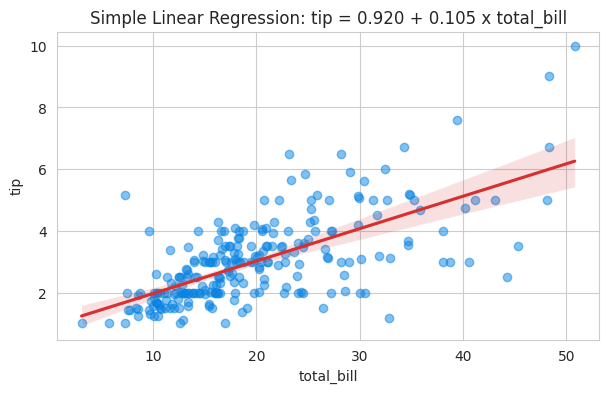

In [3]:
fig, ax = plt.subplots()
sns.regplot(data=tips, x='total_bill', y='tip', ax=ax,
            scatter_kws={'alpha': 0.5, 'color': '#0984e3'}, line_kws={'color': '#d63031'})
ax.set_title(f"Simple Linear Regression: tip = {model_simple.params['Intercept']:.3f} + {model_simple.params['total_bill']:.3f} x total_bill")
plt.show()


### 🎯 60-second challenge
Predict the tip for a $45 bill using the equation above, then verify with `model_simple.predict()`.


In [4]:
manual_prediction = model_simple.params['Intercept'] + model_simple.params['total_bill'] * 45
model_prediction = model_simple.predict(pd.DataFrame({'total_bill': [45]}))

print(f"Manual calculation: ${manual_prediction:.2f}")
print(f"Model prediction:   ${model_prediction.values[0]:.2f}")


Manual calculation: $5.65
Model prediction:   $5.65


## 2️⃣ Multiple Linear Regression — "Predict Y from SEVERAL variables at once"

### Theory

Real outcomes rarely depend on just one factor. Multiple regression extends the equation:

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_k x_k$$

Each coefficient now means: *"the effect of this variable, **holding all other variables constant**."* This is the single most important sentence in regression — it's what lets us isolate one predictor's effect from the others.

Categorical predictors (like `smoker`) get automatically converted into 0/1 dummy variables.

### Scenario
Predict `tip` from `total_bill`, `size` (party size), and `smoker` status together.


In [5]:
model_multi = smf.ols('tip ~ total_bill + size + smoker', data=tips).fit()
print(model_multi.summary())


                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.469
Model:                            OLS   Adj. R-squared:                  0.462
Method:                 Least Squares   F-statistic:                     70.57
Date:                Fri, 10 Jul 2026   Prob (F-statistic):           9.41e-33
Time:                        05:53:32   Log-Likelihood:                -347.80
No. Observations:                 244   AIC:                             703.6
Df Residuals:                     240   BIC:                             717.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.6256      0.207      3.026   

**How to read this:**
- `total_bill` coefficient: holding party size and smoker status constant, each extra $1 on the bill adds about that many cents to the tip
- `size` coefficient: holding bill and smoker status constant, each extra person at the table changes the tip by that amount
- `smoker[T.Yes]`: the difference in tip between smokers and non-smokers, holding bill and size constant — check its p-value; it's often **not** significant once bill size is accounted for
- `R-squared` should be similar to or slightly better than the simple model — more predictors rarely hurt R², but watch **Adjusted R-squared**, which penalizes adding predictors that don't really help


In [6]:
print(f"Simple model R-squared:   {model_simple.rsquared:.4f}")
print(f"Multiple model R-squared:  {model_multi.rsquared:.4f}")
print(f"Multiple model Adj. R-sq:  {model_multi.rsquared_adj:.4f}")


Simple model R-squared:   0.4566
Multiple model R-squared:  0.4687
Multiple model Adj. R-sq:  0.4620


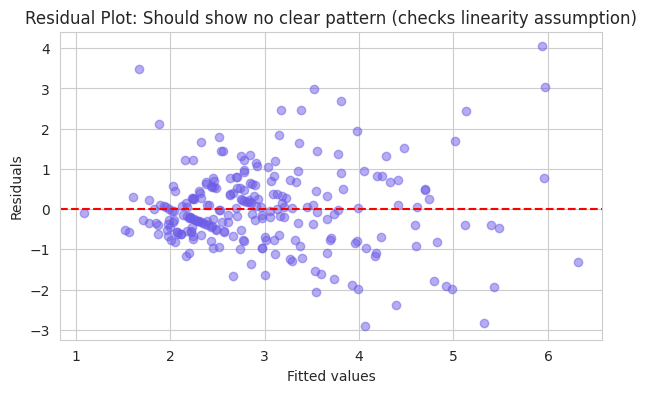

In [7]:
fig, ax = plt.subplots()
residuals = model_multi.resid
fitted = model_multi.fittedvalues
ax.scatter(fitted, residuals, alpha=0.5, color='#6c5ce7')
ax.axhline(0, color='red', linestyle='--')
ax.set_xlabel("Fitted values")
ax.set_ylabel("Residuals")
ax.set_title("Residual Plot: Should show no clear pattern (checks linearity assumption)")
plt.show()


**Reading a residual plot:** if residuals are randomly scattered around zero with no funnel shape or curve, the linear model's assumptions are reasonably satisfied. A funnel shape would suggest non-constant variance (heteroscedasticity); a curve would suggest a missing non-linear term.


## 3️⃣ Multicollinearity & VIF — "Are my predictors secretly measuring the same thing?"

### Theory

**Multicollinearity** happens when two or more predictors are highly correlated *with each other* (not just with Y). This is a problem because:
- Coefficients become unstable and hard to interpret (their sign or size can swing wildly with small data changes)
- Standard errors inflate, making truly important predictors look non-significant
- The model still predicts fine overall — but you can no longer trust individual coefficients

### Variance Inflation Factor (VIF)

VIF measures how much a predictor's variance is "inflated" due to correlation with other predictors:

$$VIF_i = \frac{1}{1 - R_i^2}$$

where $R_i^2$ comes from regressing predictor $i$ against all other predictors.

**Rule of thumb:**

| VIF | Interpretation |
|---|---|
| 1 | No correlation with other predictors |
| 1 – 5 | Moderate, usually fine |
| 5 – 10 | Concerning, investigate |
| > 10 | Serious multicollinearity — consider dropping or combining predictors |

### Practical: checking our multiple regression model


In [8]:
X = tips[['total_bill', 'size']].copy()
X = sm.add_constant(X)

vif_data = pd.DataFrame()
vif_data['Variable'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data


,Variable,VIF
0,const,8.904095
1,total_bill,1.557586
2,size,1.557586


These VIFs are all comfortably low — `total_bill` and `size` aren't secretly measuring the same thing, so we can trust their individual coefficients in the multiple regression above.

### A deliberately BAD example — engineered multicollinearity
Let's see what happens when we add a predictor that's almost a duplicate of an existing one.


In [9]:
tips_demo = tips.copy()
# Engineer a redundant variable: total_bill measured in a different currency (just total_bill * 83, plus tiny noise)
tips_demo['bill_in_rupees'] = tips_demo['total_bill'] * 83 + np.random.normal(0, 5, len(tips_demo))

X_bad = tips_demo[['total_bill', 'size', 'bill_in_rupees']].copy()
X_bad = sm.add_constant(X_bad)

vif_bad = pd.DataFrame()
vif_bad['Variable'] = X_bad.columns
vif_bad['VIF'] = [variance_inflation_factor(X_bad.values, i) for i in range(X_bad.shape[1])]
vif_bad


,Variable,VIF
0,const,8.905323
1,total_bill,23461.616756
2,size,1.558890
3,bill_in_rupees,23454.441757


**Notice:** `total_bill` and `bill_in_rupees` both show sky-high VIFs — because they're carrying almost identical information (one is just a rescaled version of the other). Including both in a model would make their individual coefficients meaningless, even though the model's overall predictions might still look fine. **The fix:** drop one of the redundant variables, or combine them, before interpreting individual coefficients.


## 4️⃣ Logistic Regression — "Predict a YES/NO outcome"

### Theory

When your outcome is **binary** (survived/died, churn/stay, click/no-click), linear regression breaks down — it can predict nonsensical values like 1.4 or −0.2 for a probability. Logistic regression fixes this by modeling the **log-odds** of the outcome:

$$\log\left(\frac{p}{1-p}\right) = \beta_0 + \beta_1 x_1 + \dots + \beta_k x_k$$

This produces an S-shaped ("sigmoid") curve that always stays between 0 and 1 — perfect for probabilities.

**Interpreting coefficients:** unlike linear regression, a logistic coefficient represents change in **log-odds**. Exponentiating it ($e^{\beta}$) gives the **odds ratio** — a much more intuitive number:
- Odds ratio > 1 → predictor increases the odds of the outcome
- Odds ratio < 1 → predictor decreases the odds of the outcome
- Odds ratio = 1 → no effect

### Scenario
Predict Titanic `survived` (1 = survived, 0 = died) from `pclass`, `sex`, `age`, and `fare`.


In [10]:
titanic_model_data = titanic.copy()
titanic_model_data['sex_male'] = (titanic_model_data['sex'] == 'male').astype(int)

logit_model = smf.logit('survived ~ pclass + sex_male + age + fare', data=titanic_model_data).fit()
print(logit_model.summary())


Optimization terminated successfully.
         Current function value: 0.453242
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:               survived   No. Observations:                  714
Model:                          Logit   Df Residuals:                      709
Method:                           MLE   Df Model:                            4
Date:                Fri, 10 Jul 2026   Pseudo R-squ.:                  0.3290
Time:                        05:53:33   Log-Likelihood:                -323.61
converged:                       True   LL-Null:                       -482.26
Covariance Type:            nonrobust   LLR p-value:                 2.020e-67
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.9880      0.572      8.717      0.000       3.867       6.110
pclass        -1.2697      0.

In [11]:
odds_ratios = np.exp(logit_model.params)
print("Odds Ratios (easier to interpret than raw log-odds coefficients):")
print(odds_ratios.round(3))

print("\nInterpretation:")
print(f"- pclass OR = {odds_ratios['pclass']:.3f} -> each step DOWN in class (1st->2nd->3rd) multiplies survival odds by ~{odds_ratios['pclass']:.2f}")
print(f"- sex_male OR = {odds_ratios['sex_male']:.3f} -> being male multiplies survival odds by ~{odds_ratios['sex_male']:.2f} (a huge drop)")
print(f"- age OR = {odds_ratios['age']:.3f} -> each additional year of age multiplies survival odds by ~{odds_ratios['age']:.3f}")
print(f"- fare OR = {odds_ratios['fare']:.3f} -> each $1 increase in fare multiplies survival odds by ~{odds_ratios['fare']:.3f}")


Odds Ratios (easier to interpret than raw log-odds coefficients):
Intercept    146.649
pclass         0.281
sex_male       0.081
age            0.964
fare           1.001
dtype: float64

Interpretation:
- pclass OR = 0.281 -> each step DOWN in class (1st->2nd->3rd) multiplies survival odds by ~0.28
- sex_male OR = 0.081 -> being male multiplies survival odds by ~0.08 (a huge drop)
- age OR = 0.964 -> each additional year of age multiplies survival odds by ~0.964
- fare OR = 1.001 -> each $1 increase in fare multiplies survival odds by ~1.001


**The story:** being male and being in a lower class both sharply reduced survival odds — consistent with "women and children first" and the class-based access we already saw with Chi-Square in Stage 5. This is a great example of two different tests (Chi-Square in Stage 5, Logistic Regression here) converging on the same real-world story from different angles.

### Model evaluation: predictions & confusion matrix


Accuracy: 0.793


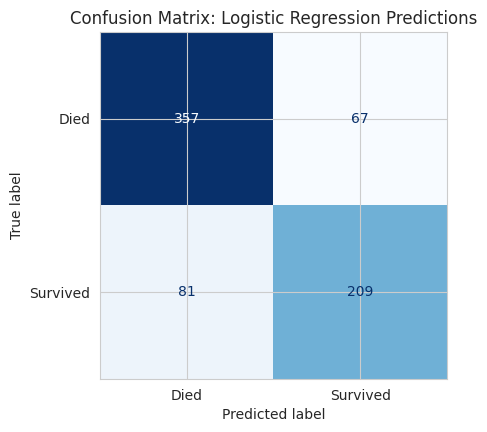

In [12]:
predicted_probs = logit_model.predict(titanic_model_data)
predicted_class = (predicted_probs >= 0.5).astype(int)

acc = accuracy_score(titanic_model_data['survived'], predicted_class)
print(f"Accuracy: {acc:.3f}")

cm = confusion_matrix(titanic_model_data['survived'], predicted_class)
fig, ax = plt.subplots(figsize=(5, 4.5))
ConfusionMatrixDisplay(cm, display_labels=['Died', 'Survived']).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title("Confusion Matrix: Logistic Regression Predictions")
plt.show()


**Reading the confusion matrix:** the diagonal cells (top-left and bottom-right) are correct predictions; the off-diagonal cells are mistakes. An accuracy around 78-80% here is respectable for a model built on just 4 predictors — in an industry setting you'd also check precision/recall (not just accuracy) depending on which type of mistake is more costly.

### Visualizing the sigmoid curve


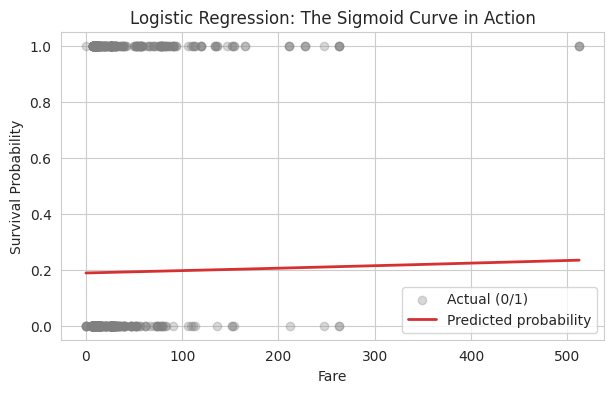

In [13]:
fig, ax = plt.subplots()
sorted_idx = titanic_model_data['fare'].argsort()
ax.scatter(titanic_model_data['fare'], titanic_model_data['survived'], alpha=0.3, color='gray', label='Actual (0/1)')

# Hold other variables at their mean/mode to visualize fare's isolated effect
fare_range = np.linspace(titanic_model_data['fare'].min(), titanic_model_data['fare'].max(), 200)
avg_row = pd.DataFrame({
    'pclass': titanic_model_data['pclass'].mean(),
    'sex_male': titanic_model_data['sex_male'].mode()[0],
    'age': titanic_model_data['age'].mean(),
    'fare': fare_range
})
predicted_curve = logit_model.predict(avg_row)

ax.plot(fare_range, predicted_curve, color='#d63031', linewidth=2, label='Predicted probability')
ax.set_xlabel("Fare")
ax.set_ylabel("Survival Probability")
ax.set_title("Logistic Regression: The Sigmoid Curve in Action")
ax.legend()
plt.show()


**The shape says it all:** unlike linear regression's straight line, this S-curve naturally flattens out near 0 and 1 — it can never predict an impossible probability like 1.3 or −0.1, no matter how extreme the fare value gets.


## 📋 Cheat Sheet — Stage 7 Recap

| Concept | One-line summary |
|---|---|
| **Simple Linear Regression** | Predict numeric Y from one numeric X: ŷ = β₀ + β₁x |
| **Multiple Linear Regression** | Predict numeric Y from several predictors; each coefficient = effect holding others constant |
| **R² / Adjusted R²** | Proportion of variance in Y explained; adjusted version penalizes useless extra predictors |
| **Multicollinearity / VIF** | Checks if predictors overlap too much with each other; VIF > 10 = serious problem |
| **Logistic Regression** | Predict a binary Y using log-odds; coefficients become odds ratios via exponentiation |
| **Confusion Matrix** | Grid of correct vs incorrect binary predictions — the starting point for accuracy, precision, recall |

### The big picture, end to end
You now have the complete toolkit: Stage 1 gave you the framework, Stages 2 taught you to check assumptions, Stages 3–4 compared groups, Stage 5 handled categories, Stage 6 measured relationships, and Stage 7 turned those relationships into working predictive models. Every technique from here on — machine learning, A/B testing, forecasting — builds directly on these foundations.
